In [1]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

# Helper Functions

In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

SRC_DIR = Path.cwd().parent
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from eda_helpers import *

CHART_DIR = Path("charts")

# Statistic summary
- Priced in April

In [3]:
PROJECT_ID = "gannett-datascience"
TABLE_ID = "gannett-datascience.test_results_zone.ss_test_result_v3-2"

NUMERIC_FIELDS = [
    "frequency",
    "breadth",
    "tenure",
    "tt_cost"
]
SEGMENT_FIELDS = [
    "src_risk_tier",
    "cohort",
    "Treatment",
    "contact_channel",
    "status",
    "contact_timing",
    "repeatedly_called"
]
IDS = [
    "billing_account",
    "id_subscrip",
    "email_date"
]

client = bigquery.Client(project=PROJECT_ID)

In [4]:
query = f"""
SELECT
  {", ".join(NUMERIC_FIELDS + SEGMENT_FIELDS + IDS)}
FROM `{TABLE_ID}`
where email_date < '2026-05-01'
"""
df = client.query(query).to_dataframe()
df = cast_numeric_fields(df, NUMERIC_FIELDS)
df['contact_channels'] = df['contact_channel'].replace({'Online first': 'Contacted both ways', 'Called-In first': 'Contacted both ways'})
df['src_risk_tier'] = df['src_risk_tier']+' risk'
df_action = df[df["status"].ne("No Action yet")].copy()
df_no_action = df[df["status"].eq("No Action yet")].copy()

In [5]:
print("Shapes:", df.shape, df_action.shape, df_no_action.shape)
df.info()

Shapes: (9398, 15) (1531, 15) (7867, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9398 entries, 0 to 9397
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   frequency          9389 non-null   float64
 1   breadth            9389 non-null   float64
 2   tenure             9389 non-null   float64
 3   tt_cost            9389 non-null   float64
 4   src_risk_tier      5644 non-null   object 
 5   cohort             9398 non-null   object 
 6   Treatment          9398 non-null   object 
 7   contact_channel    9398 non-null   object 
 8   status             9398 non-null   object 
 9   contact_timing     9398 non-null   object 
 10  repeatedly_called  9398 non-null   Int64  
 11  billing_account    9398 non-null   object 
 12  id_subscrip        9398 non-null   Int64  
 13  email_date         9398 non-null   dbdate 
 14  contact_channels   9398 non-null   object 
dtypes: Int64(2), dbdate(1), float64

In [6]:
# df.describe(include="all").T

In [7]:
percentiles = DEFAULT_PERCENTILES
dfs = {"Action": df_action, "No Action": df_no_action}

for name, df_i in dfs.items():
    print(f"Distribution Summary for {name} users:")
    distribution_summary = build_distribution_summary(df_i, NUMERIC_FIELDS, percentiles)
    display(distribution_summary)

Distribution Summary for Action users:


,field,row_count,null_count,null_pct,zero_count,negative_count,min,max,mean,median,std,p01,p05,p10,p25,p50,p75,p90,p95,p99
0,frequency,1531,3,0.20,183,0,0.00,91.00,45.90,46.00,34.53,0.00,0.00,0.00,9.00,46.00,82.00,90.00,91.00,91.00
1,breadth,1531,3,0.20,292,0,0.00,20.00,5.04,4.00,4.19,0.00,0.00,0.00,1.00,4.00,8.00,11.00,13.00,15.73
2,tenure,1531,3,0.20,0,0,323.00,"11,789.00","1,501.89","1,450.00",820.37,325.27,358.35,689.70,"1,144.00","1,450.00","1,728.25","2,332.00","2,639.65","3,790.92"
3,tt_cost,1531,3,0.20,0,0,25.91,"3,925.74",504.38,462.87,336.87,108.23,119.76,169.16,289.29,462.87,621.14,826.45,"1,005.34","1,788.55"


Distribution Summary for No Action users:


,field,row_count,null_count,null_pct,zero_count,negative_count,min,max,mean,median,std,p01,p05,p10,p25,p50,p75,p90,p95,p99
0,frequency,7867,6,0.08,1632,0,0.00,91.00,38.46,29.00,35.37,0.00,0.00,0.00,2.00,29.00,77.00,90.00,91.00,91.00
1,breadth,7867,6,0.08,2466,0,0.00,21.00,4.18,3.00,4.24,0.00,0.00,0.00,0.00,3.00,7.00,10.00,12.00,16.00
2,tenure,7867,6,0.08,0,0,208.00,"27,867.00","1,382.95","1,354.00",886.36,324.00,337.00,504.00,997.00,"1,354.00","1,635.00","2,069.00","2,460.00","3,405.80"
3,tt_cost,7867,6,0.08,32,0,0.00,"9,279.71",571.25,502.83,439.16,107.89,112.89,166.27,374.25,502.83,704.96,949.38,"1,279.15","1,764.45"


# Vis - Histogram

In [8]:
for col in NUMERIC_FIELDS:
    for name, df_i in dfs.items():
        for col in NUMERIC_FIELDS:
            for name, df_i in dfs.items():
                plot_histogram_with_log(
                    data=df_i,
                    metric=col,
                    group=name,
                    chart_folder=str(CHART_DIR / "histograms" / name),
                )

# Vis - Boxplot

In [9]:
for col in NUMERIC_FIELDS:
    for name, df_i in dfs.items():
        plot_full_and_clipped_boxplot(
            df_i,
            col,
            name,
            chart_folder=str(CHART_DIR / "boxplots" / name),
        )

In [10]:
outlier_df = build_outlier_summary(dfs["Action"], NUMERIC_FIELDS)
outlier_df

,field,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
0,frequency,9.00,82.00,73.00,-100.50,191.50,0,0.00
1,breadth,1.00,8.00,7.00,-9.50,18.50,1,0.07
2,tenure,"1,144.00","1,728.25",584.25,267.62,"2,604.62",87,5.68
3,tt_cost,289.29,621.14,331.85,-208.48,"1,118.91",60,3.92


In [11]:
outlier_df = build_outlier_summary(dfs["No Action"], NUMERIC_FIELDS)
outlier_df

,field,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
0,frequency,2.00,77.00,75.00,-110.50,189.50,0,0.00
1,breadth,0.00,7.00,7.00,-10.50,17.50,22,0.28
2,tenure,997.00,"1,635.00",638.00,40.00,"2,592.00",281,3.57
3,tt_cost,374.25,704.96,330.71,-121.82,"1,201.03",458,5.82


# Vis - Correlation, Pairplot, Scatterplot

In [12]:
for name, df_i in dfs.items():
    plot_correlation_heatmap(
        df_i,
        NUMERIC_FIELDS,
        name,
        chart_folder=str(CHART_DIR / "correlations" / name),
    )

In [54]:
# sample_df = df[NUMERIC_FIELDS].dropna().sample(
#     min(5000, len(df.dropna())),
#     random_state=42
# )

# sns.pairplot(sample_df)
# plt.show()

In [13]:
pairs = [
    ("frequency", "breadth"),
    ("frequency", "tenure"),
    ("frequency", "tt_cost"),
    ("breadth", "tenure"),
    ("breadth", "tt_cost"),
    ("tenure", "tt_cost")
]

for name, df_i in dfs.items():
    plot_scatter_pairs(
        df_i,
        pairs,
        chart_folder=str(CHART_DIR / "scatter" / name),
        file_name="{pair}.png",
    )

# Vis - Custom bucket

In [14]:
for name, df_i in dfs.items():
    df_i["tenure_bucket"] = pd.cut(
        df_i["tenure"],
        bins=[-np.inf, 0, 30, 90, 180, 365, 730, np.inf],
        labels=[
            "0 or less",
            "1-30 days",
            "31-90 days",
            "91-180 days",
            "181-365 days",
            "1-2 years",
            "2+ years"
        ]
    )
    bucket_cols = ["tenure_bucket"] #, "cost_bucket", "frequency_bucket"]
    for col in bucket_cols:
        bucket_counts = plot_bucket_counts(
            df_i,
            col,
            chart_folder=str(CHART_DIR / "bucket_counts" / name),
        )
        display(bucket_counts)

,tenure_bucket,count
0,2+ years,1348
1,1-2 years,102
2,181-365 days,78
3,NaN,3
4,0 or less,0
5,1-30 days,0
6,31-90 days,0
7,91-180 days,0


,tenure_bucket,count
0,2+ years,6694
1,181-365 days,721
2,1-2 years,446
3,NaN,6
4,0 or less,0
5,1-30 days,0
6,31-90 days,0
7,91-180 days,0


# Vis - Boxplots of Segments

In [9]:
for segment in SEGMENT_FIELDS:
    if segment in df.columns:
        print(f"\nSegment summary by {segment}")
        segment_summary = build_segment_summary(df, segment)
        display(segment_summary)


Segment summary by src_risk_tier


,src_risk_tier,users,avg_frequency,median_frequency,p90_frequency,avg_breadth,median_breadth,p90_breadth,avg_tenure,median_tenure,avg_total_cost,median_total_cost,p90_total_cost
0,1. Low risk,2461,71.35,84.00,91.00,6.71,7.00,12.00,"1,580.67","1,509.00",596.19,505.65,"1,059.79"
2,3. Medium risk,1437,10.33,3.00,34.00,1.74,0.00,6.00,"1,281.19","1,328.00",586.08,553.78,887.56
1,2. Med-Low risk,1264,40.00,40.00,71.00,5.02,5.00,10.00,"1,519.93","1,454.50",689.72,614.03,"1,252.63"
3,4. Med-High risk,449,7.05,3.00,19.20,1.54,0.00,5.00,903.63,863.00,384.52,382.74,528.75
4,5. High risk,33,12.48,1.00,74.40,2.64,1.00,9.60,821.52,"1,121.00",270.76,413.25,609.39



Segment summary by cohort


,cohort,users,avg_frequency,median_frequency,p90_frequency,avg_breadth,median_breadth,p90_breadth,avg_tenure,median_tenure,avg_total_cost,median_total_cost,p90_total_cost
0,Three-Offer Cohort,5644,43.33,40.50,90.00,4.63,4.00,11.00,"1,432.52","1,361.00",595.82,514.89,"1,012.99"
1,Two-Offer Cohort,3754,34.16,20.00,88.60,3.86,2.00,10.00,"1,356.78","1,363.00",506.93,472.86,802.96



Segment summary by Treatment


...

,status,users,avg_frequency,median_frequency,p90_frequency,avg_breadth,median_breadth,p90_breadth,avg_tenure,median_tenure,avg_total_cost,median_total_cost,p90_total_cost
0,No Action yet,7867,38.46,29.00,90.00,4.18,3.00,10.00,"1,382.95","1,354.00",571.25,502.83,949.38
2,stoped,942,39.35,33.00,89.00,4.64,4.00,11.00,"1,476.51","1,421.00",526.75,483.85,839.16
1,saved,589,56.41,67.00,91.00,5.69,5.00,11.00,"1,542.57","1,454.00",468.53,428.24,788.32



Segment summary by contact_timing


,contact_timing,users,avg_frequency,median_frequency,p90_frequency,avg_breadth,median_breadth,p90_breadth,avg_tenure,median_tenure,avg_total_cost,median_total_cost,p90_total_cost
1,Contact On/After Pricing,8409,38.95,30.00,90.00,4.23,3.00,10.00,"1,387.69","1,359.00",565.98,502.50,931.82
0,Contact Before Pricing,989,45.86,46.00,90.00,5.12,5.00,11.00,"1,526.59","1,451.00",512.66,463.54,847.28



Segment summary by repeatedly_called


,repeatedly_called,users,avg_frequency,median_frequency,p90_frequency,avg_breadth,median_breadth,p90_breadth,avg_tenure,median_tenure,avg_total_cost,median_total_cost,p90_total_cost
0,0,9385,39.63,32.00,90.00,4.32,3.00,10.00,"1,402.03","1,362.00",560.56,499.17,908.88
1,1,13,73.00,89.00,91.00,6.00,5.00,9.90,"1,619.92","1,432.00",407.48,418.10,701.71


In [10]:
for segment in SEGMENT_FIELDS:
    segments_order = ORDERS.get(segment)
    plot_df = df[df[segment].isin(segments_order)]

    plot_metrics_by_group(
        data=plot_df,
        metrics=NUMERIC_FIELDS,
        group_col=segment,
        order=segments_order,
        rotate_xticks=True,
        figsize=(10, 5),
        chart_folder=str(CHART_DIR / "metrics_by_segment"),
        file_name=f"metrics_{segment}.png",
    )

# Business Boxplots

## No Action vs Had Action

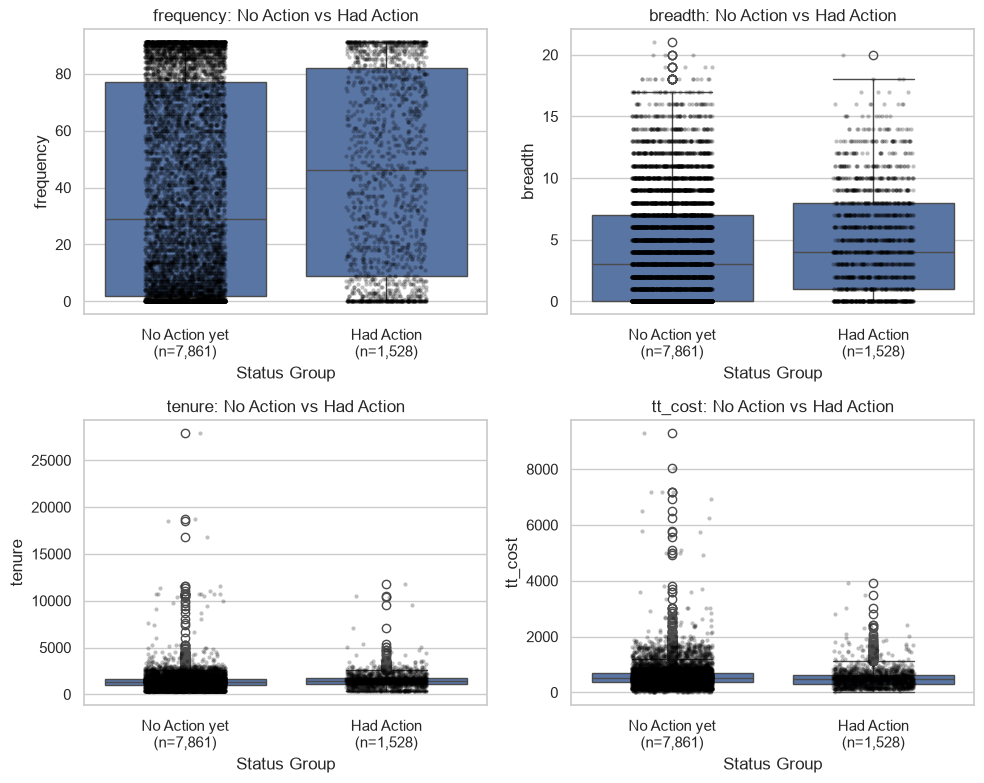

In [ ]:
df["action_group"] = np.where(
    df["status"].eq("No Action yet"),
    "No Action yet",
    "Had Action"
)

action_order = ["No Action yet", "Had Action"]

_ = plot_metrics_by_group(
    data=df,
    metrics=NUMERIC_FIELDS,
    group_col="action_group",
    order=action_order,
    chart_title="Metrics: No Action vs Had Action",
    figsize=(10, 5),
    chart_folder=str(CHART_DIR / "status_metrics"),
    file_name="no_action_vs_had_action.png",
)

## Repeated Caller Among Had Action

In [17]:
df_action["repeated_call_group"] = np.where(
    df_action["repeatedly_called"].fillna(0).astype(int).eq(1),
    "Repeatedly Called",
    "Not Repeatedly Called"
)

repeated_call_order = ["Not Repeatedly Called", "Repeatedly Called"]

_ = plot_metrics_by_group(
    data=df_action,
    metrics=NUMERIC_FIELDS,
    group_col="repeated_call_group",
    order=repeated_call_order,
    chart_title="Metrics: Repeated Caller Among Had Action",
    figsize=(10, 5),
    chart_folder=str(CHART_DIR / "status_metrics"),
    file_name="repeated_caller_among_had_action.png",
)

## Treatment Comparison Within Segment Slice

## Available Segment Combinations

In [18]:
slice_fields=["contact_channels", "cohort", "src_risk_tier", "contact_timing"]
res = build_segment_combo_counts(
    df_action,
    metrics=NUMERIC_FIELDS,
    slice_fields=slice_fields,
    chart_folder=str(CHART_DIR / "segment_combo_metrics"),
    file_name_template="combo_{combo_index}_{segment_combo}.png",
)

,contact_channels,cohort,src_risk_tier,contact_timing,Treatment,users
0,Called-In Cancel Flow,Three-Offer Cohort,1. Low risk,Contact Before Pricing,Control,87
1,Called-In Cancel Flow,Three-Offer Cohort,1. Low risk,Contact Before Pricing,Midpoint,84
2,Called-In Cancel Flow,Three-Offer Cohort,1. Low risk,Contact Before Pricing,Tiered,75
3,Called-In Cancel Flow,Three-Offer Cohort,1. Low risk,Contact On/After Pricing,Control,41
4,Called-In Cancel Flow,Three-Offer Cohort,1. Low risk,Contact On/After Pricing,Midpoint,50


Plotting 29 unique segment combinations...
No groups meet the minimum sample size.
No groups meet the minimum sample size.
No groups meet the minimum sample size.
No groups meet the minimum sample size.
No groups meet the minimum sample size.
No groups meet the minimum sample size.
No groups meet the minimum sample size.
No groups meet the minimum sample size.
No groups meet the minimum sample size.
No groups meet the minimum sample size.


# WIP

In [62]:
# distribution_summary.to_csv("distribution_summary.csv")
# quality_df.to_csv("data_quality_summary.csv", index=False)
# outlier_df.to_csv("outlier_summary.csv", index=False)

# print("Saved summary files.")

In [63]:
# percentile_query = f"""
# SELECT
#   COUNT(*) AS row_count,

#   APPROX_QUANTILES(tenure, 100)[OFFSET(1)] AS tenure_p01,
#   APPROX_QUANTILES(tenure, 100)[OFFSET(25)] AS tenure_p25,
#   APPROX_QUANTILES(tenure, 100)[OFFSET(50)] AS tenure_p50,
#   APPROX_QUANTILES(tenure, 100)[OFFSET(75)] AS tenure_p75,
#   APPROX_QUANTILES(tenure, 100)[OFFSET(90)] AS tenure_p90,
#   APPROX_QUANTILES(tenure, 100)[OFFSET(95)] AS tenure_p95,
#   APPROX_QUANTILES(tenure, 100)[OFFSET(99)] AS tenure_p99,

#   APPROX_QUANTILES(total_cost, 100)[OFFSET(1)] AS total_cost_p01,
#   APPROX_QUANTILES(total_cost, 100)[OFFSET(25)] AS total_cost_p25,
#   APPROX_QUANTILES(total_cost, 100)[OFFSET(50)] AS total_cost_p50,
#   APPROX_QUANTILES(total_cost, 100)[OFFSET(75)] AS total_cost_p75,
#   APPROX_QUANTILES(total_cost, 100)[OFFSET(90)] AS total_cost_p90,
#   APPROX_QUANTILES(total_cost, 100)[OFFSET(95)] AS total_cost_p95,
#   APPROX_QUANTILES(total_cost, 100)[OFFSET(99)] AS total_cost_p99,

#   APPROX_QUANTILES(viewed_number_of_pages, 100)[OFFSET(1)] AS pages_p01,
#   APPROX_QUANTILES(viewed_number_of_pages, 100)[OFFSET(25)] AS pages_p25,
#   APPROX_QUANTILES(viewed_number_of_pages, 100)[OFFSET(50)] AS pages_p50,
#   APPROX_QUANTILES(viewed_number_of_pages, 100)[OFFSET(75)] AS pages_p75,
#   APPROX_QUANTILES(viewed_number_of_pages, 100)[OFFSET(90)] AS pages_p90,
#   APPROX_QUANTILES(viewed_number_of_pages, 100)[OFFSET(95)] AS pages_p95,
#   APPROX_QUANTILES(viewed_number_of_pages, 100)[OFFSET(99)] AS pages_p99

# FROM `{TABLE_ID}`
# """

# percentiles_bq = client.query(percentile_query).to_dataframe()
# percentiles_bq